Raw dataset counts:
       1and1  AMD  ATandT  Alfa Romeo  Alpha Tauri  Alpinestars  Aramco  \
train     32   60      32         276          388          224     396   
val        0    6       2          22           25           11      19   
test       2    4       3          18           25           10      19   

       Arrow Electronics  Aston Martin  BWT AG  ...  fia  fxpro  gulf  hp  \
train                 48           704     580  ...  112     44    56  24   
val                    5            48      35  ...    4      4     2   0   
test                   1            49      40  ...    8      1     1   1   

       lavazza  logitech  stc  ural kali  verti  wallmart  
train       20        16   44         32     28        80  
val          2         2    0          0      2         2  
test         1         0    3          2      2         4  

[3 rows x 86 columns]

Stratified dataset counts:
       1and1  AMD  ATandT  Alfa Romeo  Alpha Tauri  Alpinestars  Aramco  \
trai

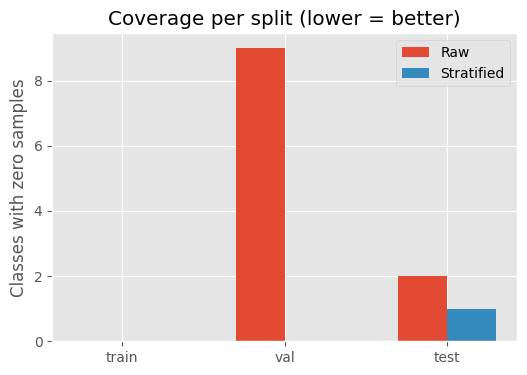

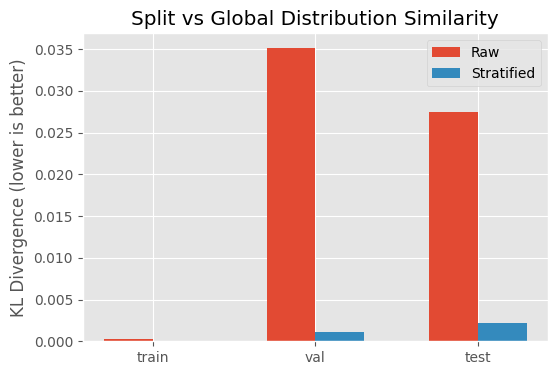

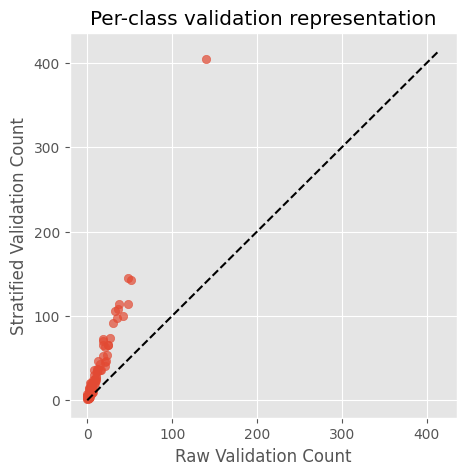

=== UNDER-REPRESENTATION METRICS ===
      Dataset  Split  Zero classes  <5 samples  <10 samples  % zero   % <5  \
0         Raw  train             0           0            2    0.00   0.00   
1         Raw    val             9          36           53   10.47  41.86   
2         Raw   test             2          34           50    2.33  39.53   
3  Stratified  train             0           0            2    0.00   0.00   
4  Stratified    val             0          12           27    0.00  13.95   
5  Stratified   test             1          19           37    1.16  22.09   

   % <10  
0   2.33  
1  61.63  
2  58.14  
3   2.33  
4  31.40  
5  43.02  

=== KL DIVERGENCE (lower = closer to global) ===
      Dataset  Split  KL Divergence
0         Raw  train         0.0002
1         Raw    val         0.0351
2         Raw   test         0.0274
0  Stratified  train         0.0001
1  Stratified    val         0.0011
2  Stratified   test         0.0022


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== STEP 1. Paste your JSON data =====
with open("class_counts_by_split.json", "r") as f:
    raw_data = json.load(f)

# raw_data has keys: "names", "totals", "counts"
names = raw_data["names"]              # list of class names
raw_counts = raw_data["counts"]        # dict of {split: {class_id: count}}

# Convert to DataFrame (splits as rows, class_id as columns)
raw_df = pd.DataFrame(raw_counts).T.fillna(0).astype(int)
raw_df.columns = [names[int(i)] for i in raw_df.columns]   # apply names

# === 2. Load the stratified JSON ===
with open("class_counts_by_split_v1.json", "r") as f:
    strat_data = json.load(f)

# stratified JSON already looks like {split: {class_id: count}}
strat_df = pd.DataFrame(strat_data).T.fillna(0).astype(int)
strat_df.columns = [names[int(i)] for i in strat_df.columns]   # reuse same names

print("Raw dataset counts:")
print(raw_df.head())

print("\nStratified dataset counts:")
print(strat_df.head())


# ===== STEP 3. Helper metrics =====
def imbalance_metrics(df, label):
    rows = []
    for split in df.index:
        s = df.loc[split]
        total_classes = len(s)
        zeros = (s == 0).sum()
        under5 = (s < 5).sum()
        under10 = (s < 10).sum()
        rows.append({
            "Dataset": label,
            "Split": split,
            "Zero classes": zeros,
            "<5 samples": under5,
            "<10 samples": under10,
            "% zero": 100*zeros/total_classes,
            "% <5": 100*under5/total_classes,
            "% <10": 100*under10/total_classes
        })
    return pd.DataFrame(rows)

raw_metrics = imbalance_metrics(raw_df, "Raw")
strat_metrics = imbalance_metrics(strat_df, "Stratified")

metrics_df = pd.concat([raw_metrics, strat_metrics], ignore_index=True)

# ===== STEP 4. Compare distribution similarity =====
def kl_divergence(p, q):
    p, q = np.asarray(p), np.asarray(q)
    p = np.where(p == 0, 1e-10, p)
    q = np.where(q == 0, 1e-10, q)
    return np.sum(p * np.log(p / q))

def distribution_similarity(df, label):
    total = df.sum(axis=0)
    global_p = total / total.sum()
    rows = []
    for split in df.index:
        p = df.loc[split] / df.loc[split].sum()
        kl = kl_divergence(p, global_p)
        rows.append({"Dataset": label, "Split": split, "KL Divergence": kl})
    return pd.DataFrame(rows)

raw_kl = distribution_similarity(raw_df, "Raw")
strat_kl = distribution_similarity(strat_df, "Stratified")
kl_df = pd.concat([raw_kl, strat_kl])

# ===== STEP 5. Plot metrics =====
plt.style.use("ggplot")

# (A) Zero class comparison
fig, ax = plt.subplots(figsize=(6,4))
raw_vals = raw_metrics["Zero classes"]
strat_vals = strat_metrics["Zero classes"]
x = np.arange(len(raw_metrics["Split"]))
ax.bar(x-0.15, raw_vals, width=0.3, label="Raw")
ax.bar(x+0.15, strat_vals, width=0.3, label="Stratified")
ax.set_xticks(x)
ax.set_xticklabels(raw_metrics["Split"])
ax.set_ylabel("Classes with zero samples")
ax.set_title("Coverage per split (lower = better)")
ax.legend()
plt.show()

# (B) KL divergence
fig, ax = plt.subplots(figsize=(6,4))
raw_vals = raw_kl["KL Divergence"]
strat_vals = strat_kl["KL Divergence"]
ax.bar(x-0.15, raw_vals, width=0.3, label="Raw")
ax.bar(x+0.15, strat_vals, width=0.3, label="Stratified")
ax.set_xticks(x)
ax.set_xticklabels(["train", "val", "test"])
ax.set_ylabel("KL Divergence (lower is better)")
ax.set_title("Split vs Global Distribution Similarity")
ax.legend()
plt.show()

# (C) Scatter plot for validation counts
classes = raw_df.columns
raw_val = raw_df.loc["val", classes].values
strat_val = strat_df.loc["val", classes].values
plt.figure(figsize=(5,5))
plt.scatter(raw_val, strat_val, alpha=0.7)
lim = max(raw_val.max(), strat_val.max()) + 10
plt.plot([0,lim],[0,lim],'--',color='black')
plt.xlabel("Raw Validation Count")
plt.ylabel("Stratified Validation Count")
plt.title("Per-class validation representation")
plt.show()

# ===== STEP 6. Show summary tables =====
print("=== UNDER-REPRESENTATION METRICS ===")
print(metrics_df.round(2))

print("\n=== KL DIVERGENCE (lower = closer to global) ===")
print(kl_df.round(4))

